In [1]:
from snc_sf.selection_function import SNCSelectionFunction
import matplotlib.pylab as plt
import os
import numpy as np
import polars as pl
%matplotlib inline
plt.style.use('%s/mystyle.mplstyle' % os.environ['MPL_STYLES'])


sncsf = SNCSelectionFunction('../../obs_100pc_dr19.csv')

In [2]:
sncsf.coord

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [( 44.66073005,  0.51747065, 65.67350535),
     ( 44.93731565,  0.62379328, 63.80764209),
     ( 44.41500319,  0.56790054, 91.15874615), ...,
     (315.96599299, -1.54759721, 59.73068791),
     (314.39870482, -1.13995845, 37.7174195 ),
     (314.79672197, -0.28816516, 97.47159627)]>

In [3]:
Gbins = np.arange(sncsf.subSF_mock_dict['phot_g_mean_mag'][0],
                  sncsf.subSF_mock_dict['phot_g_mean_mag'][1],
                  sncsf.subSF_mock_dict['phot_g_mean_mag'][2])

GRPbins = np.arange(sncsf.subSF_mock_dict['g_rp'][0],
                    sncsf.subSF_mock_dict['g_rp'][1],
                    sncsf.subSF_mock_dict['g_rp'][2])

Gbins[52], GRPbins[15]



(np.float64(16.0), np.float64(1.0999999999999996))

In [4]:
from snc_sf.utils import calc_subsample_p
import healpy as hp

filtered = sncsf.subsamp.filter((pl.col('phot_g_mean_mag_') == 44) & (pl.col('g_rp_') == 15))

RNG = np.random.default_rng(666)

healpix = np.arange(hp.order2npix(sncsf.subSF_mock_dict['healpix']))

km = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
km[np.array(filtered['healpix_'])] = np.array(filtered['km'])

nm = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
nm[np.array(filtered['healpix_'])] = np.array(filtered['nm'])

k = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
k[np.array(filtered['healpix_'])] = np.array(filtered['k'])

n = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
n[np.array(filtered['healpix_'])] = np.array(filtered['n'])

samps = np.zeros((hp.order2npix(sncsf.subSF_mock_dict['healpix']), 1000))

for i in range(1000):
    samps[:, i] = calc_subsample_p(
                km,
                nm,
                k,
                n,
                RNG)

/Users/imedan/anaconda3/envs/snc_sf/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


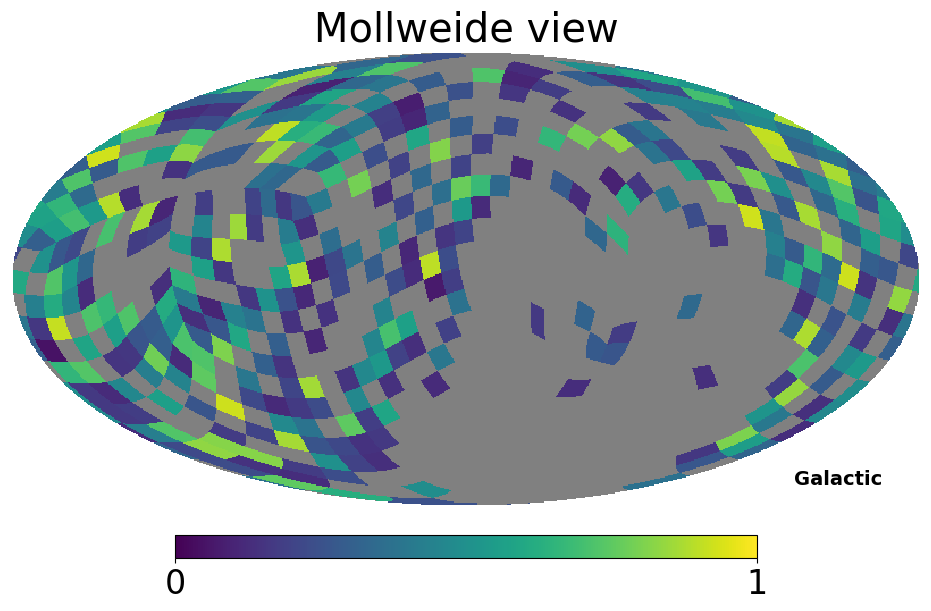

In [5]:


medianp = np.nanmedian(samps, axis=1)

plt.figure(figsize=(15, 7))
hp.mollview(medianp,hold = True,min = 0,max = 1,coord = 'CG')



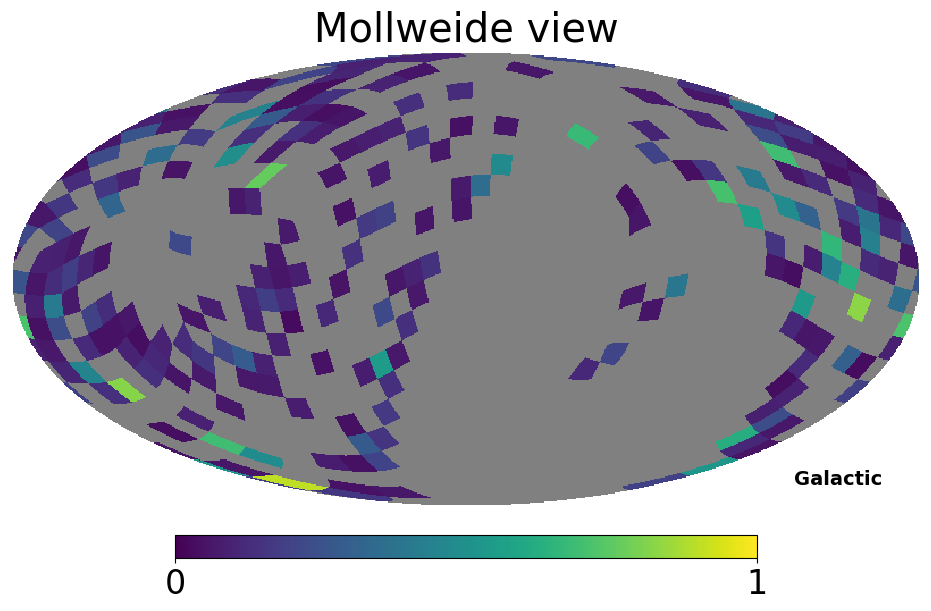

In [6]:
filtered = sncsf.subsamp.filter((pl.col('phot_g_mean_mag_') == 52) & (pl.col('g_rp_') == 16))

RNG = np.random.default_rng(666)

healpix = np.arange(hp.order2npix(sncsf.subSF_mock_dict['healpix']))

km = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
km[np.array(filtered['healpix_'])] = np.array(filtered['km'])

nm = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
nm[np.array(filtered['healpix_'])] = np.array(filtered['nm'])

k = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
k[np.array(filtered['healpix_'])] = np.array(filtered['k'])

n = np.zeros(hp.order2npix(sncsf.subSF_mock_dict['healpix'])) + np.nan
n[np.array(filtered['healpix_'])] = np.array(filtered['n'])

samps = np.zeros((hp.order2npix(sncsf.subSF_mock_dict['healpix']), 1000))

for i in range(1000):
    samps[:, i] = calc_subsample_p(
                km,
                nm,
                k,
                n,
                RNG)

medianp = np.nanmedian(samps, axis=1)

plt.figure(figsize=(15, 7))
hp.mollview(medianp,hold = True,min = 0,max = 1,coord = 'CG')




In [7]:
median_cmd = np.zeros((len(GRPbins), len(Gbins)))

for i in range(len(GRPbins)):
    for j in range(len(Gbins)):
        idx = np.where((np.array(sncsf.subsamp['g_rp_']) == i) & (np.array(sncsf.subsamp['phot_g_mean_mag_']) == j))[0]
        if len(idx) > 0:
            samps = calc_subsample_p(
                            np.zeros(1000) + np.nansum(sncsf.subsamp['km'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['nm'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['k'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['n'][idx]),
                            RNG)
            median_cmd[i][j] = np.median(samps)
        else:
            median_cmd[i][j] = np.nan

In [8]:
import astropy.coordinates as coord
import astropy.units as u

nside = hp.order2nside(sncsf.subSF_mock_dict['healpix'])
npix = hp.order2npix(sncsf.subSF_mock_dict['healpix'])
ipix = np.arange(npix)
ra, dec = hp.pix2ang(nside, ipix, lonlat=True, nest=True)
sc = coord.SkyCoord(ra * u.deg, dec * u.deg)

In [9]:
median_cmd_lowlat = np.zeros((len(GRPbins), len(Gbins)))

for i in range(len(GRPbins)):
    for j in range(len(Gbins)):
        idx = np.where((np.isin(sncsf.subsamp['healpix_'], ipix[abs(sc.galactic.b.deg) < 10])) \
                       & (np.array(sncsf.subsamp['g_rp_']) == i) \
                       & (np.array(sncsf.subsamp['phot_g_mean_mag_']) == j))[0]
        if len(idx) > 0:
            samps = calc_subsample_p(
                            np.zeros(1000) + np.nansum(sncsf.subsamp['km'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['nm'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['k'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['n'][idx]),
                            RNG)
            median_cmd_lowlat[i][j] = np.median(samps)
        else:
            median_cmd_lowlat[i][j] = np.nan


In [10]:
median_cmd_highlat = np.zeros((len(GRPbins), len(Gbins)))

for i in range(len(GRPbins)):
    for j in range(len(Gbins)):
        idx = np.where((np.isin(sncsf.subsamp['healpix_'], ipix[abs(sc.galactic.b.deg) > 55])) \
                       & (np.array(sncsf.subsamp['g_rp_']) == i) \
                       & (np.array(sncsf.subsamp['phot_g_mean_mag_']) == j))[0]
        if len(idx) > 0:
            samps = calc_subsample_p(
                            np.zeros(1000) + np.nansum(sncsf.subsamp['km'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['nm'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['k'][idx]),
                            np.zeros(1000) +np.nansum(sncsf.subsamp['n'][idx]),
                            RNG)
            median_cmd_highlat[i][j] = np.median(samps)
        else:
            median_cmd_highlat[i][j] = np.nan


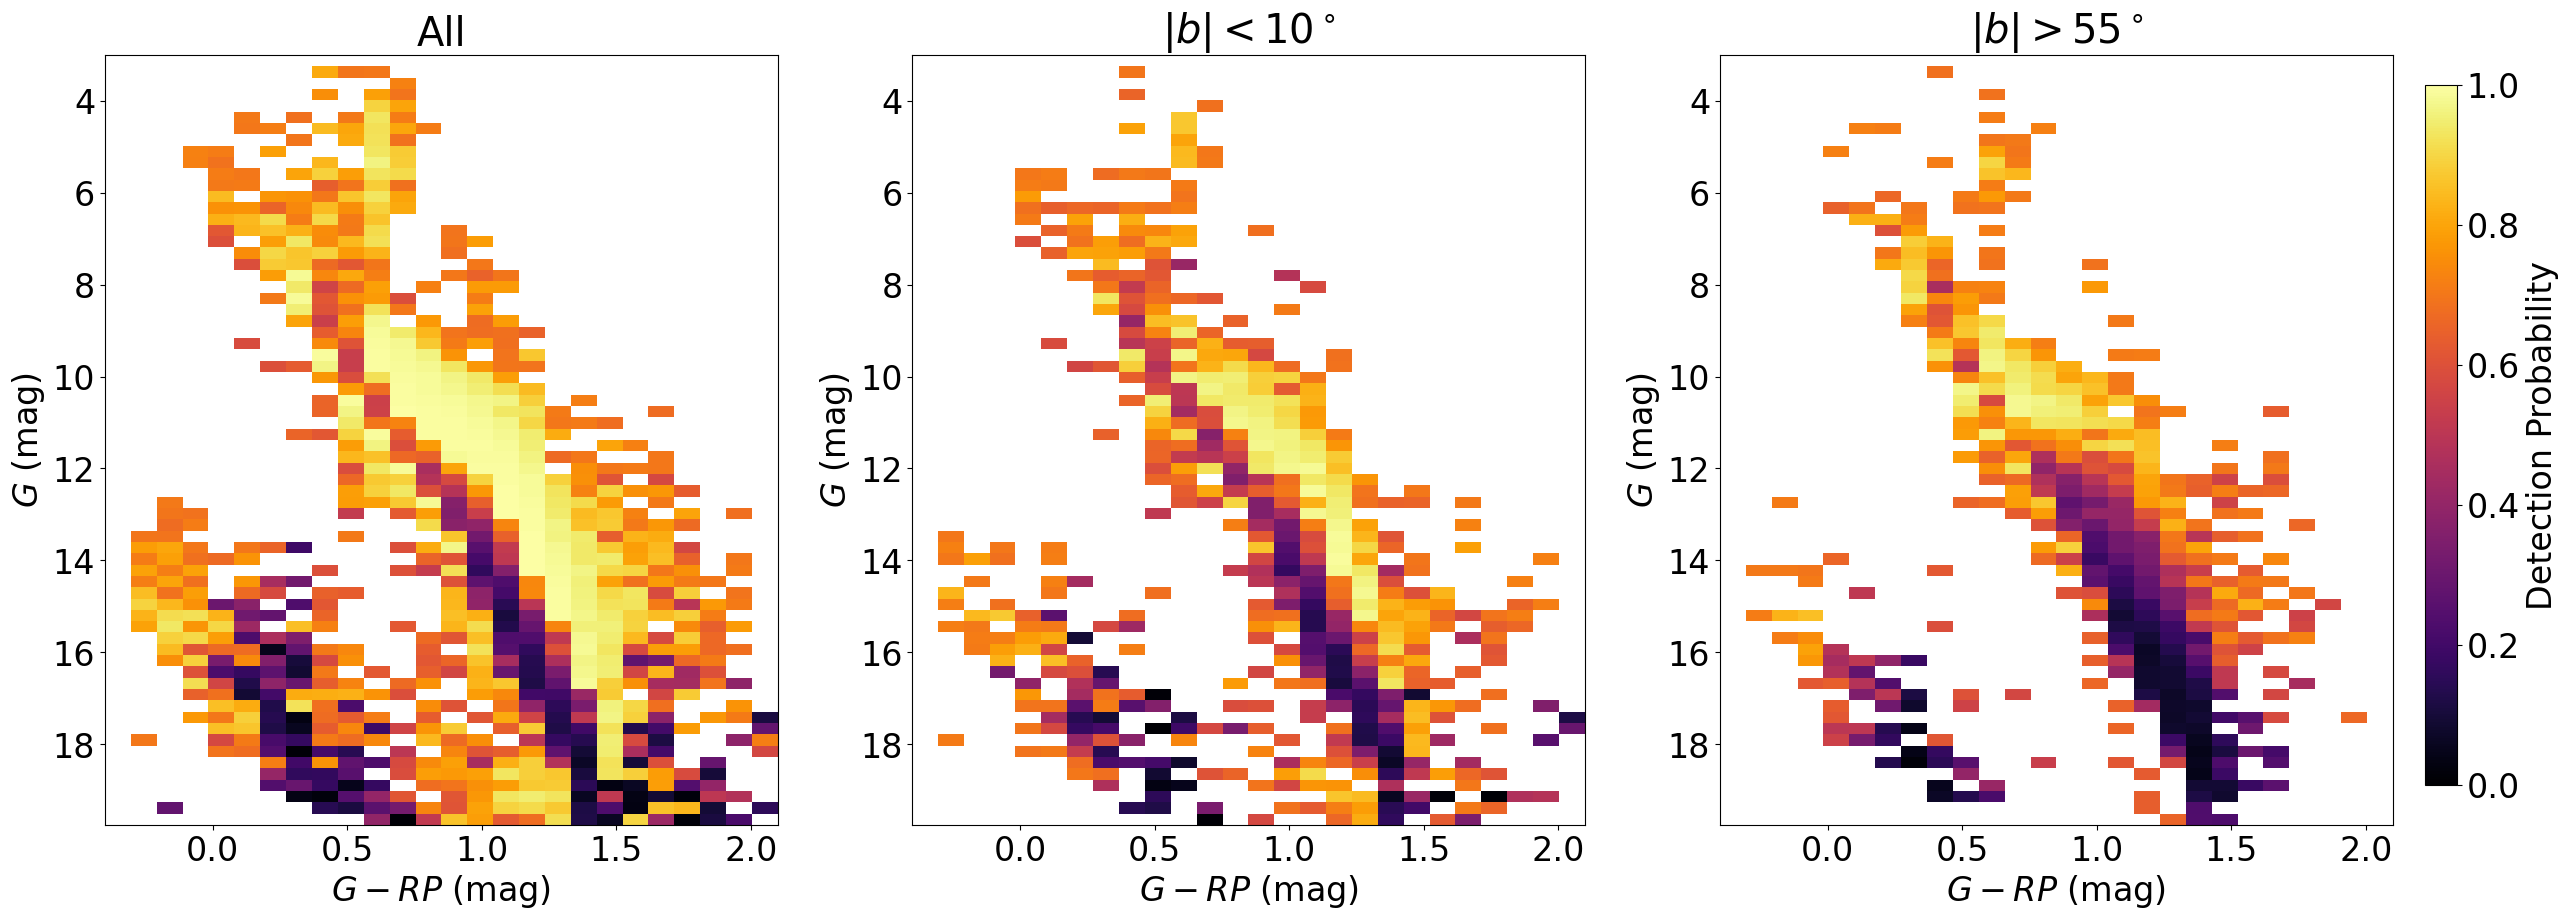

In [11]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(32, 10))

ax1.imshow(median_cmd.T, origin='lower', aspect='auto',
           extent=(GRPbins.min(), GRPbins.max(), Gbins.min(), Gbins.max()), vmin=0, vmax=1, cmap='inferno')
ax1.set_title('All')

ax2.imshow(median_cmd_lowlat.T, origin='lower', aspect='auto',
           extent=(GRPbins.min(), GRPbins.max(), Gbins.min(), Gbins.max()), vmin=0, vmax=1, cmap='inferno')
ax2.set_title(r'$|b| < 10^\circ$')

dens = ax3.imshow(median_cmd_highlat.T, origin='lower', aspect='auto',
           extent=(GRPbins.min(), GRPbins.max(), Gbins.min(), Gbins.max()), vmin=0, vmax=1, cmap='inferno')
ax3.set_title(r'$|b| > 55^\circ$')

for ax in [ax1, ax2, ax3]:
    ax.invert_yaxis()
    ax.set_xlabel(r'$G-RP$ (mag)')
    ax.set_ylabel(r'$G$ (mag)')

f.subplots_adjust(right=0.84)
cbar_ax = f.add_axes([0.85, 0.15, 0.01, 0.7])
f.colorbar(dens, cax=cbar_ax, label=r'Detection Probability')

plt.savefig('paper_plots/CMD_detection_prob.png', bbox_inches='tight')

plt.show()
